In [1]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

## Load configs and forward model

Read configuration and collect the data 

In [2]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

Load the forward model 

In [3]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Read old and new data

In [6]:
adata_loop1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO014/Loop2_Loop2p5_Loop3_Loop4_Loop4p5/Loop2_logicle_500k.h5ad")
adata_loop2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO014/Loop2_Loop2p5_Loop3_Loop4_Loop4p5/Loop2p5_logicle_500k.h5ad")

adata_loop2.obs["cell_type"] = "Unannotated"
adata_loop2p5.obs["cell_type"] = "Unannotated"

In [8]:
sc.tl.pca(adata_loop2)
sc.pp.neighbors(adata_loop2)
sc.tl.umap(adata_loop2)

sc.tl.pca(adata_loop2p5)
sc.pp.neighbors(adata_loop2p5)
sc.tl.umap(adata_loop2p5)

## Annotate cells based on markers 

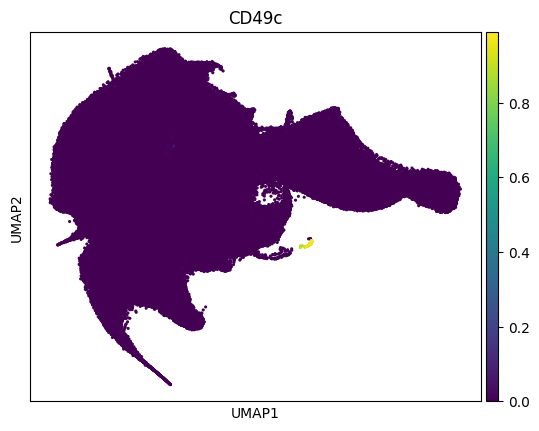

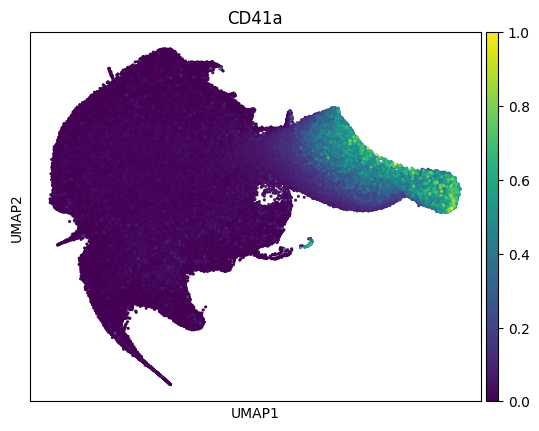

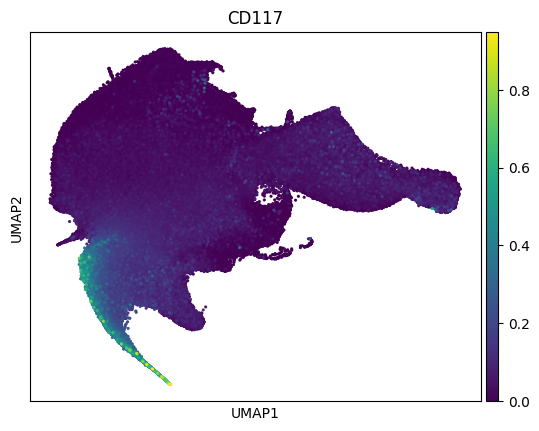

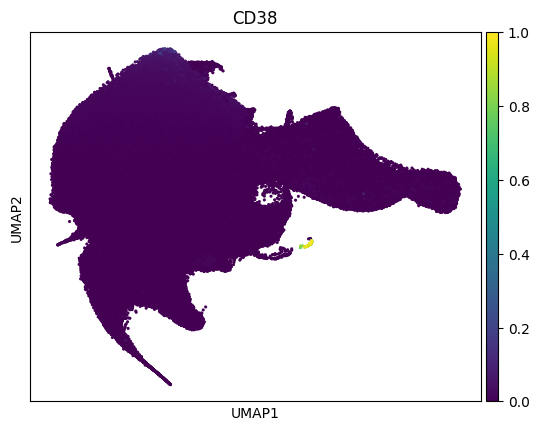

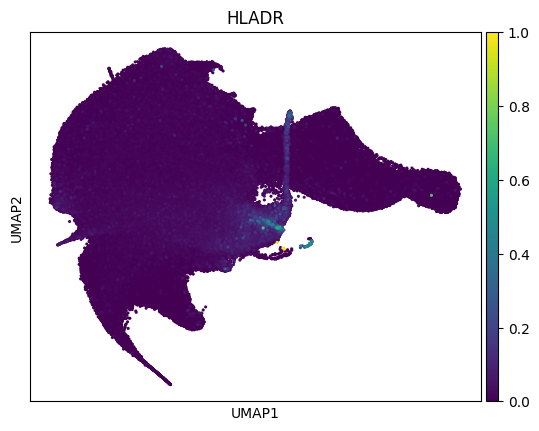

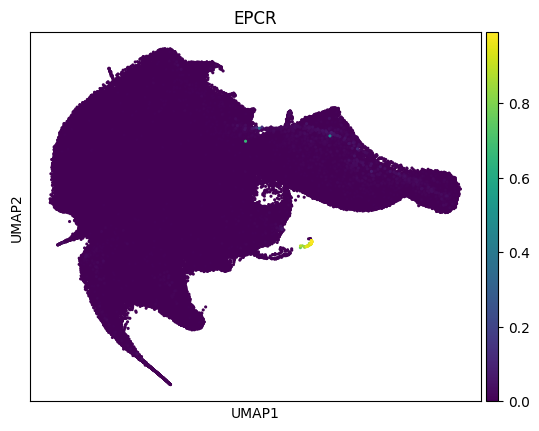

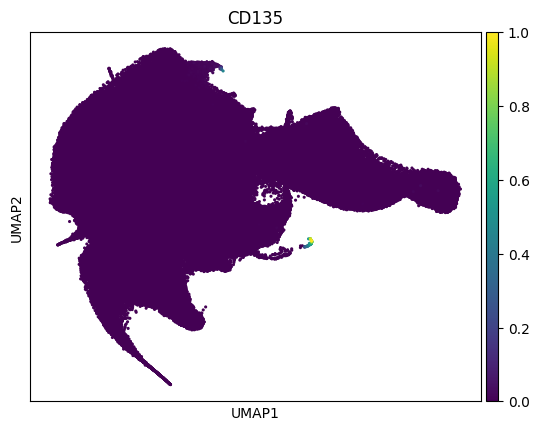

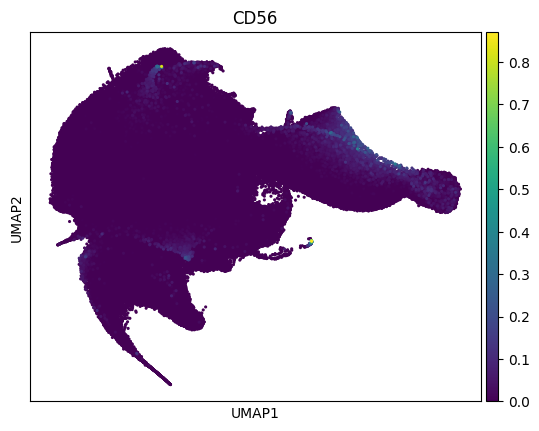

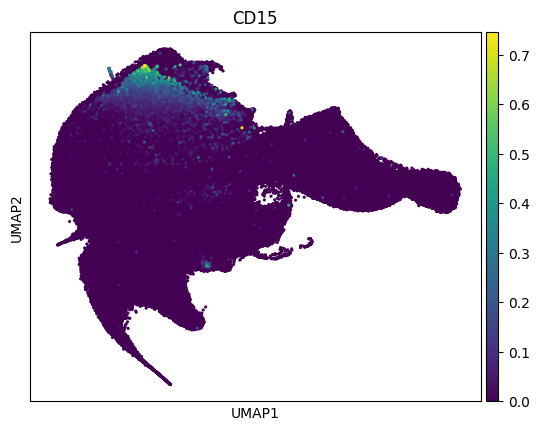

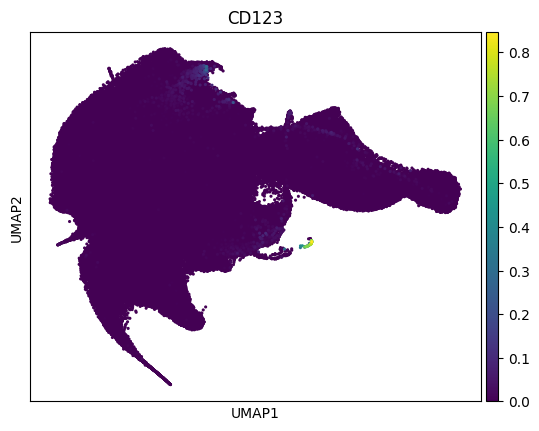

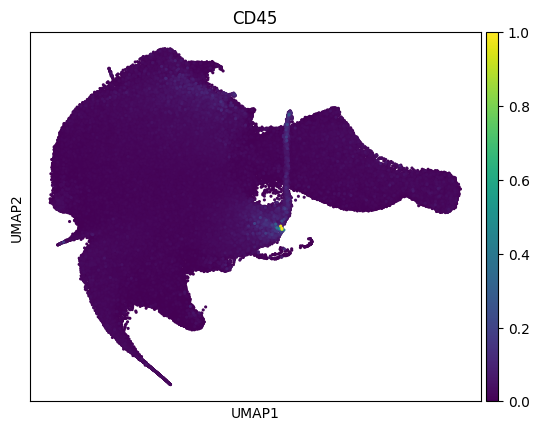

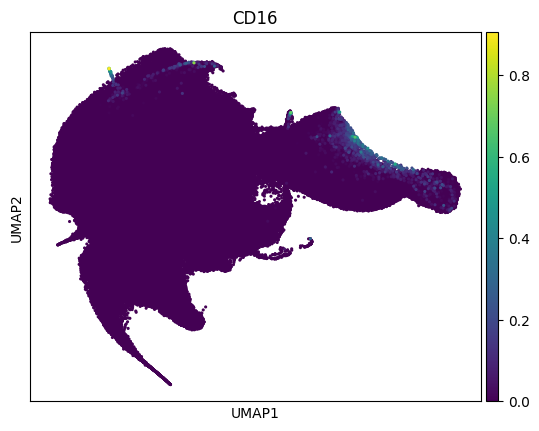

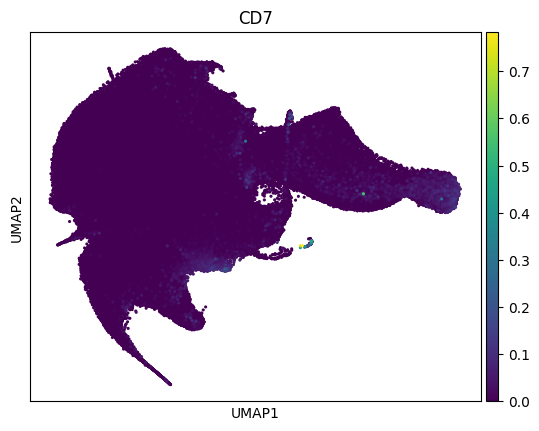

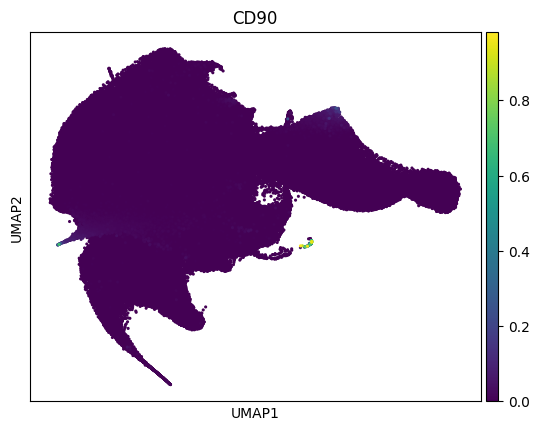

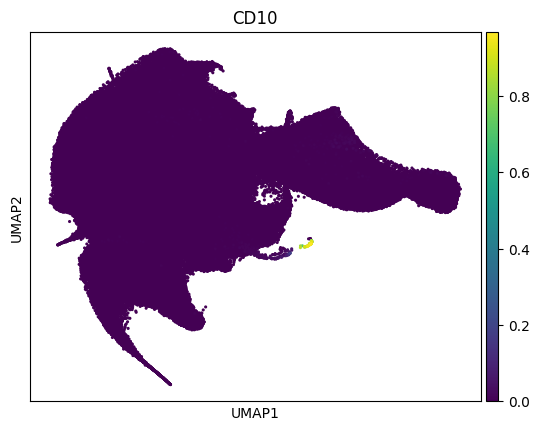

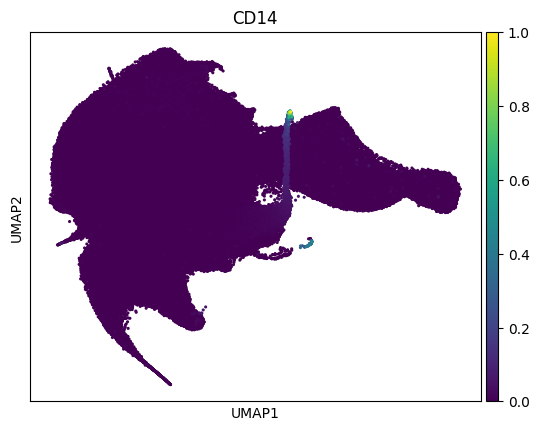

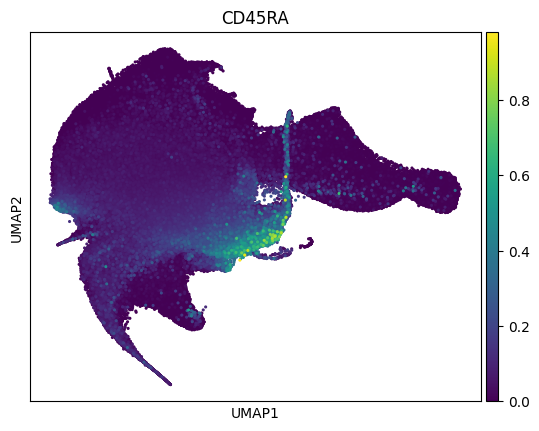

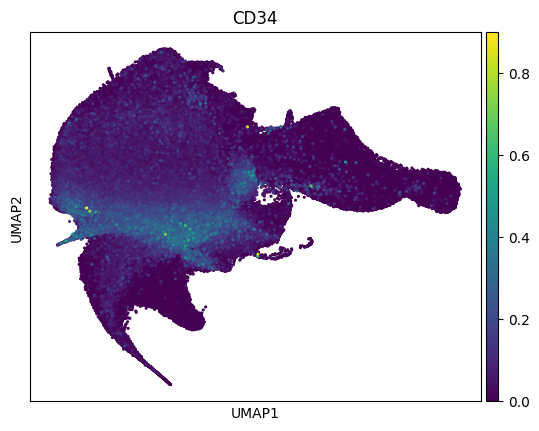

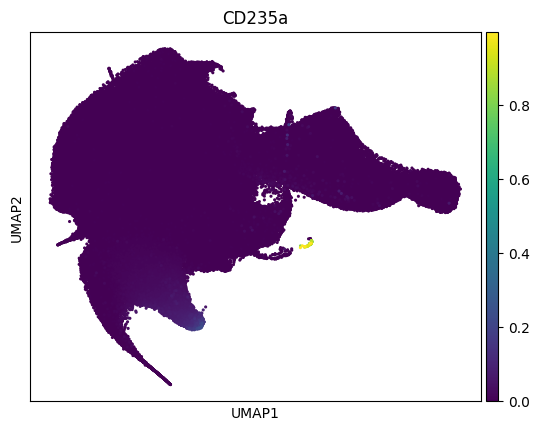

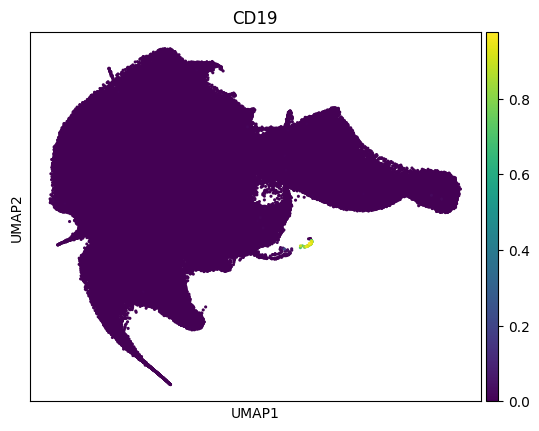

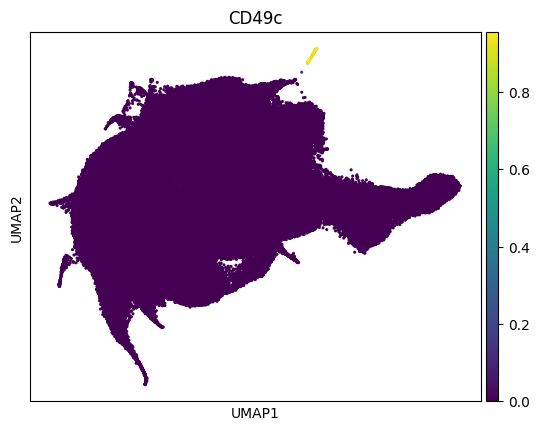

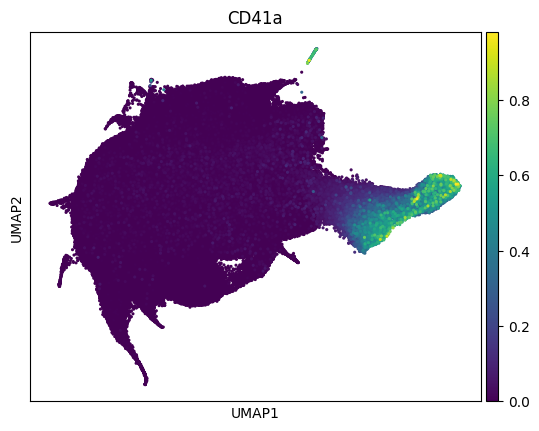

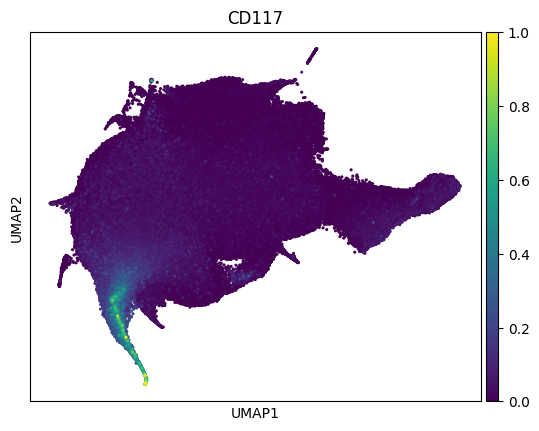

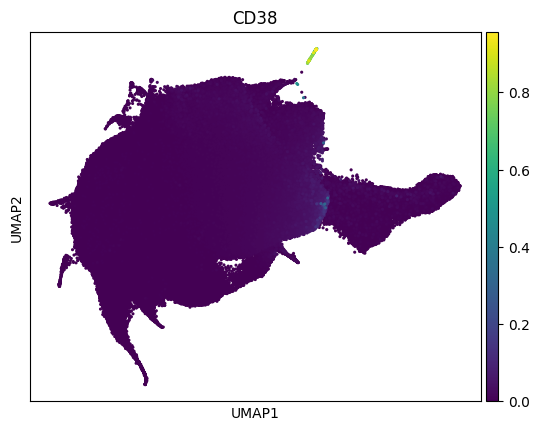

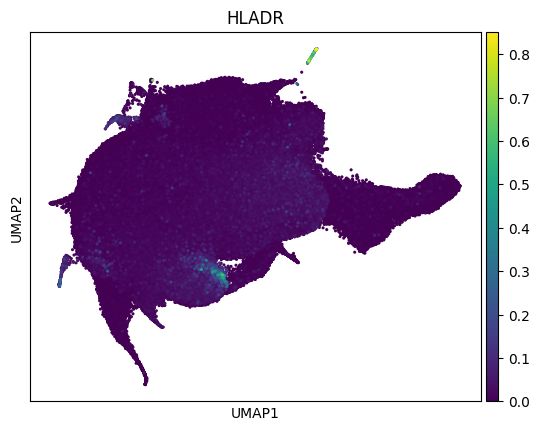

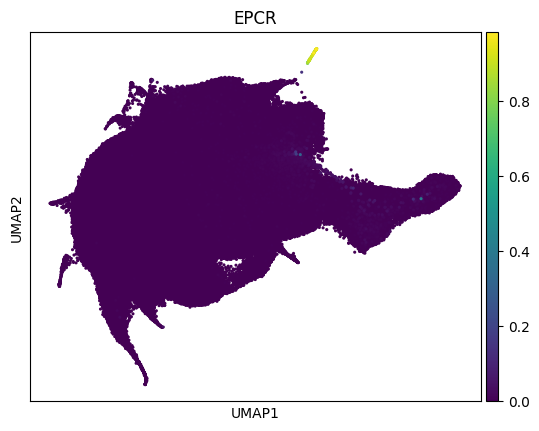

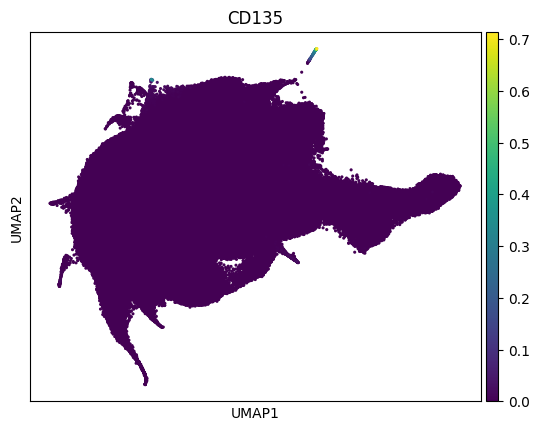

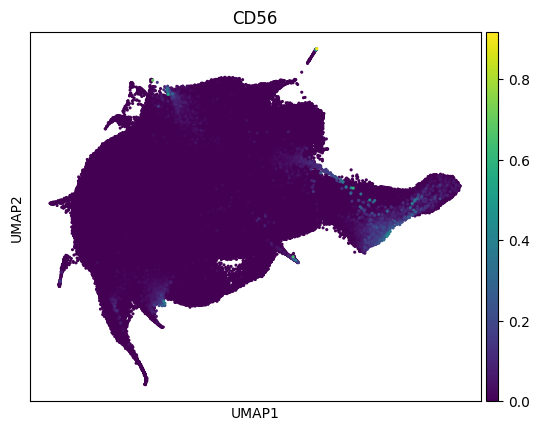

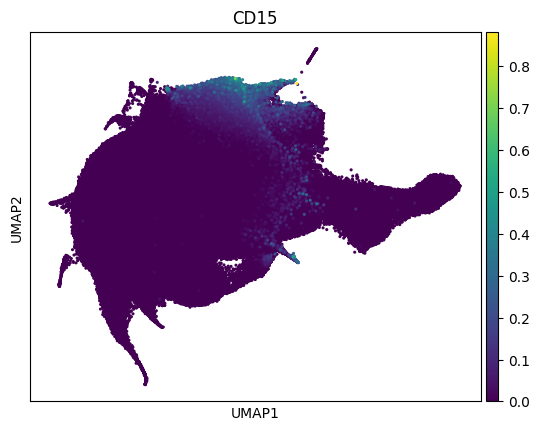

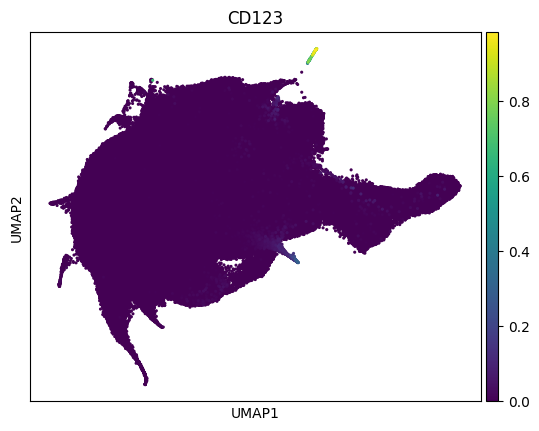

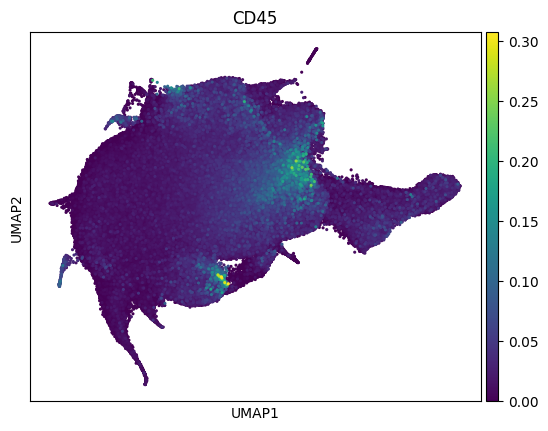

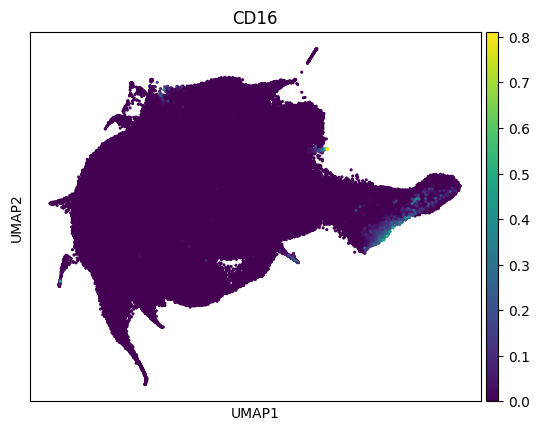

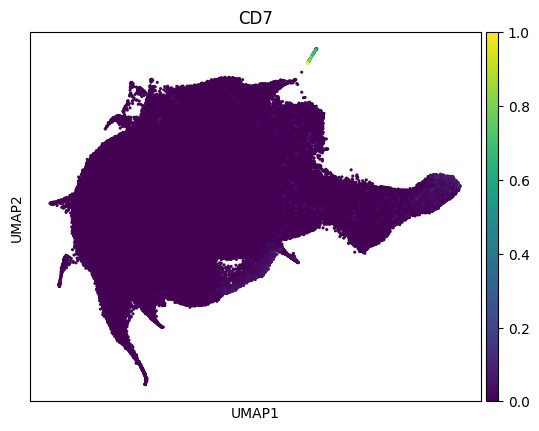

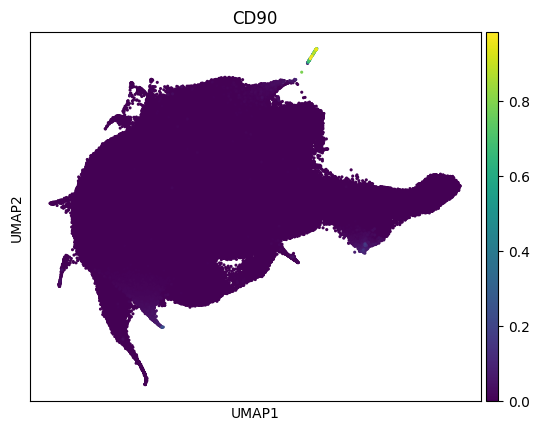

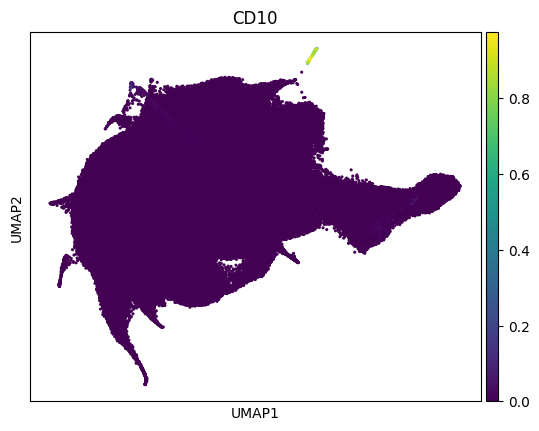

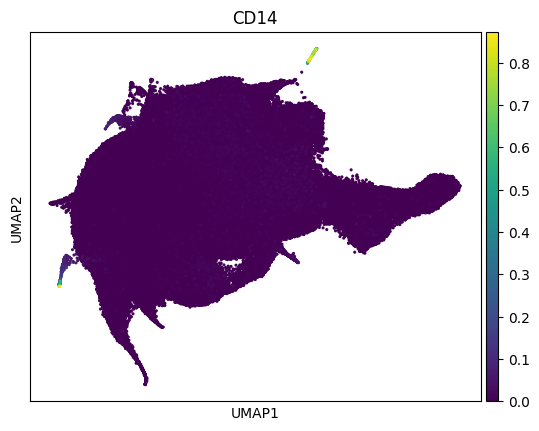

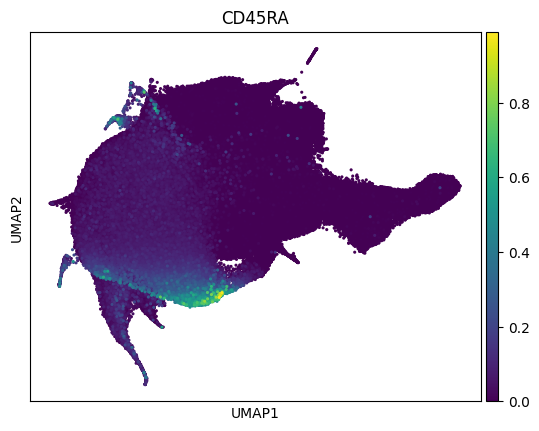

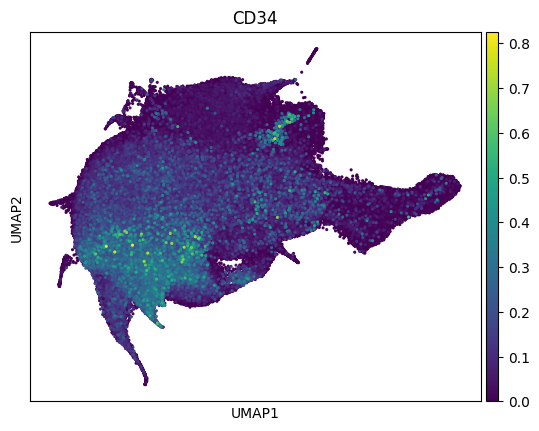

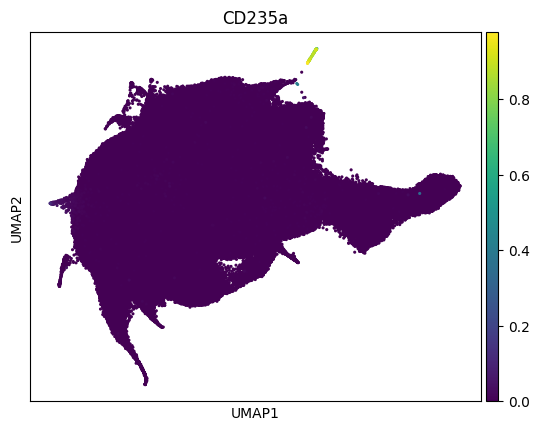

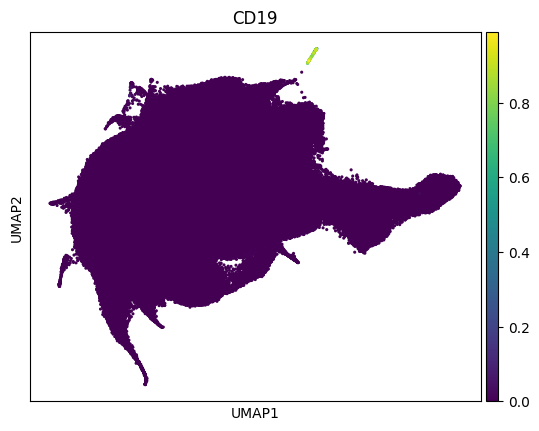

In [9]:
for marker in adata_loop2.var.index:
    sc.pl.umap(adata_loop2, s=20, color=marker)

for marker in adata_loop2p5.var.index:
    sc.pl.umap(adata_loop2p5, s=20, color=marker)

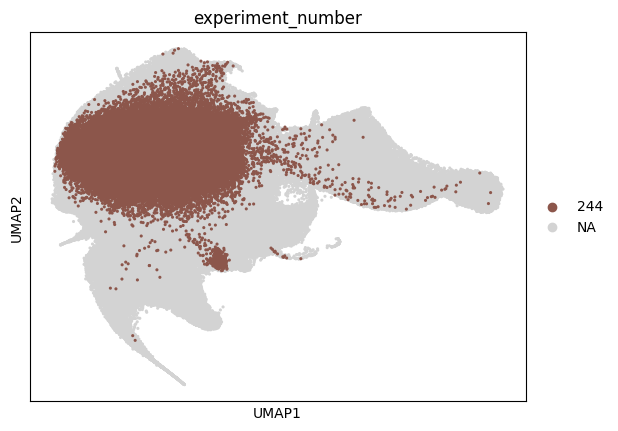

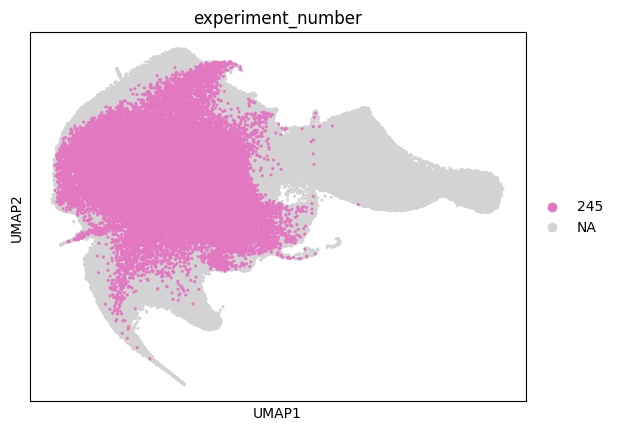

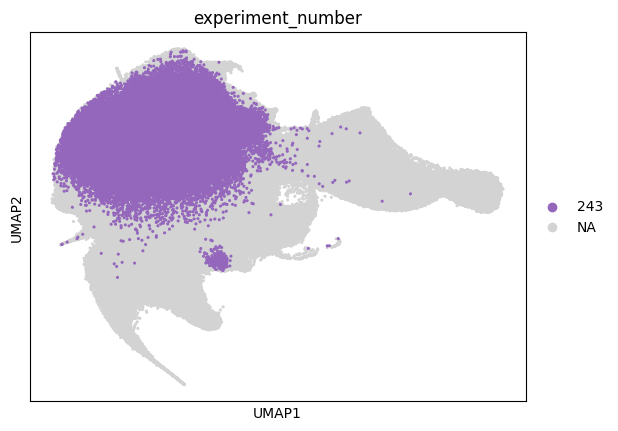

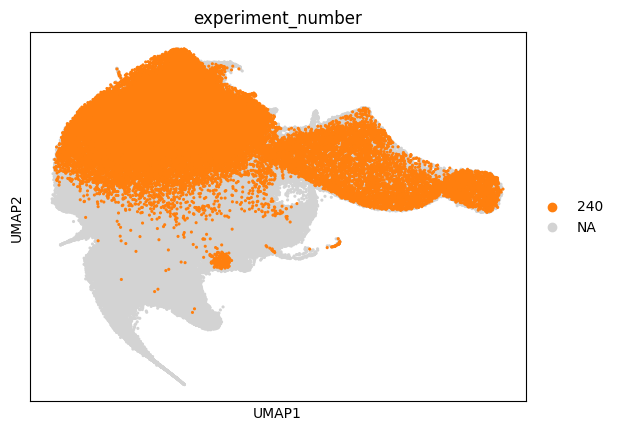

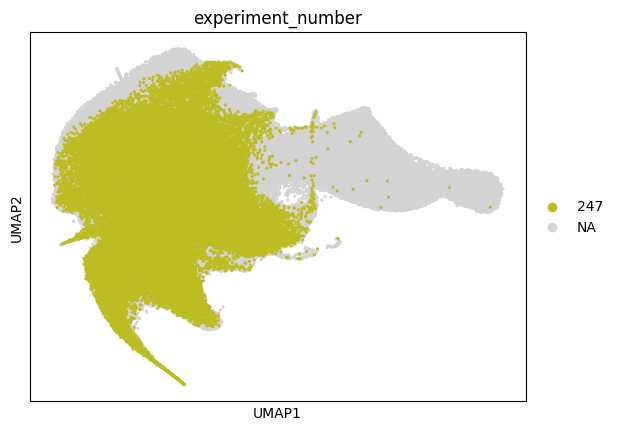

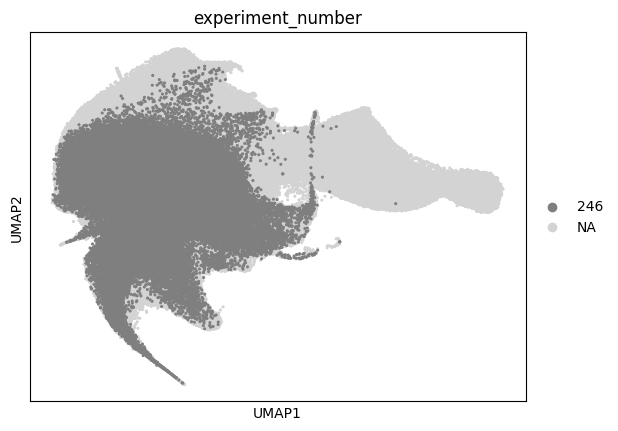

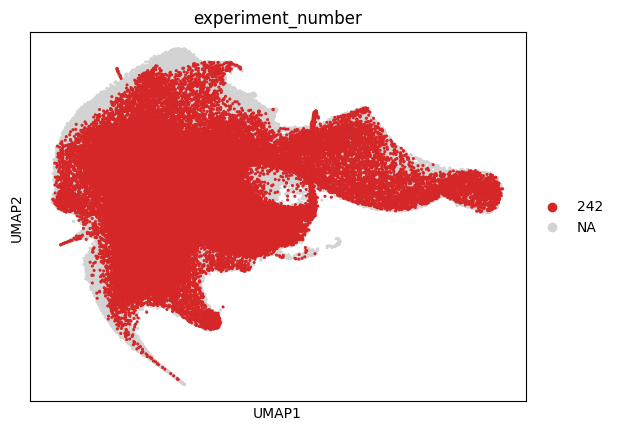

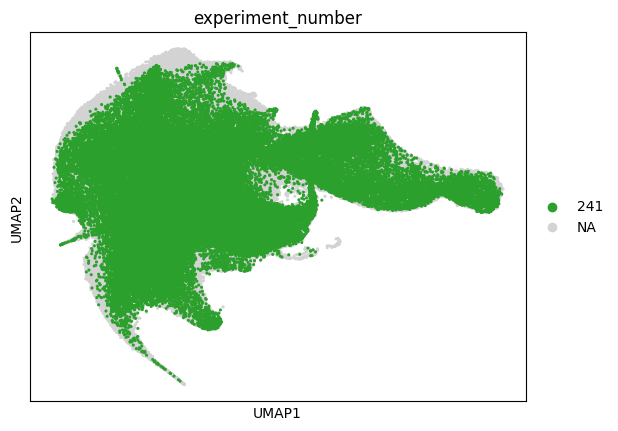

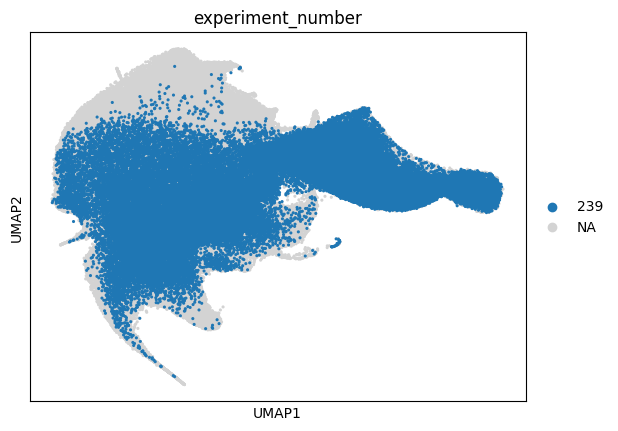

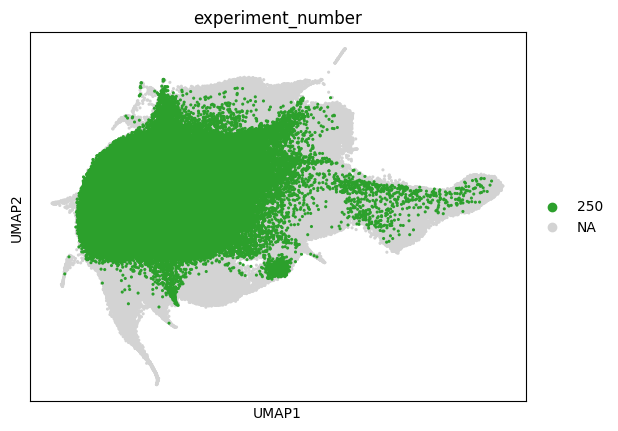

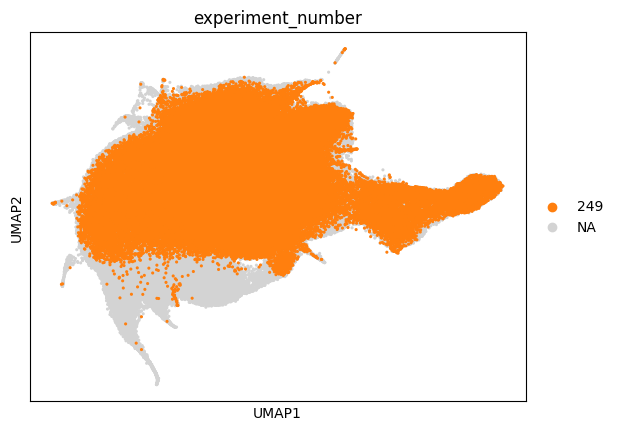

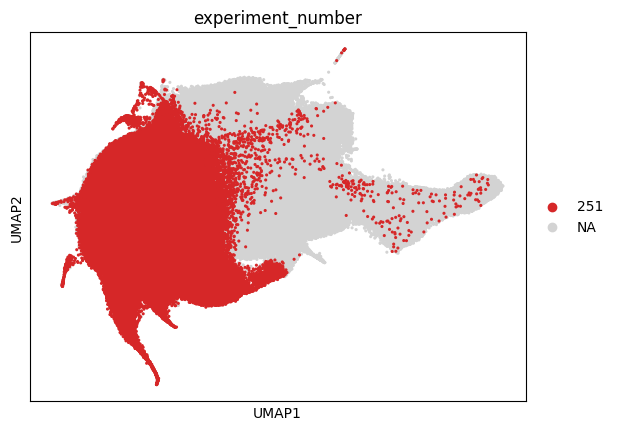

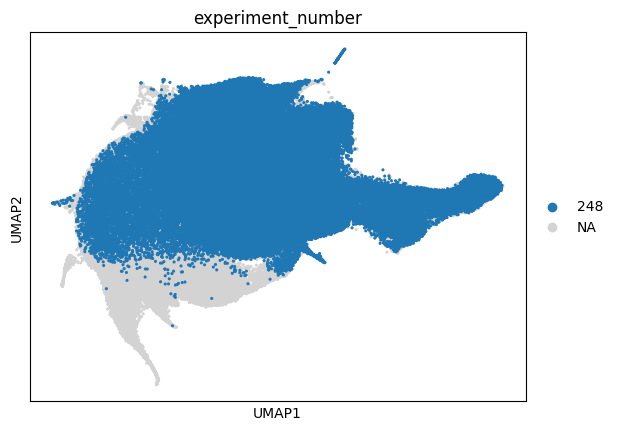

In [10]:
for exp in adata_loop2.obs.experiment_number.unique():
    sc.pl.umap(adata_loop2, s=20, color="experiment_number", groups=exp)

for exp in adata_loop2p5.obs.experiment_number.unique():
    sc.pl.umap(adata_loop2p5, s=20, color="experiment_number", groups=exp)

# Annotate cells based on markers 

In [11]:
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

(dict_keys(['mean', 'std']), dict_keys(['mean', 'std']))

In [70]:
adata_loop1.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_loop1.obs.columns
]

adata_loop2.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_loop2.obs.columns
]

adata_loop2p5.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_loop2p5.obs.columns
]

In [18]:
X_channel_loop2 = adata_loop2.X
X_channel_loop2p5 = adata_loop2p5.X

# The model 
X_channel_loop2 = (X_channel_loop2 - channel_params["mean"])/channel_params["std"]
X_channel_loop2p5 = (X_channel_loop2p5 - channel_params["mean"])/channel_params["std"]

X_scatter_loop2 = []
X_scatter_loop2p5 = []
for col in config.annotation.scatter_columns:
    col_vals_loop2 = adata_loop2.obs[col].astype(float).values
    col_vals_loop2p5 = adata_loop2p5.obs[col].astype(float).values
    X_scatter_loop2.append(col_vals_loop2)
    X_scatter_loop2p5.append(col_vals_loop2p5)
    
X_scatter_loop2 = np.stack(X_scatter_loop2, axis=1)
X_scatter_loop2 = (X_scatter_loop2 - scatter_params["mean"])/scatter_params["std"]
X_scatter_loop2p5 = np.stack(X_scatter_loop2p5, axis=1)
X_scatter_loop2p5 = (X_scatter_loop2p5 - scatter_params["mean"])/scatter_params["std"]


X_loop2 = np.concatenate(
    (
        X_channel_loop2, X_scatter_loop2
    ), axis=1
)

X_loop2p5 = np.concatenate(
    (
        X_channel_loop2p5, X_scatter_loop2p5
    ), axis=1
)

print(f"{X_channel_loop2.shape=} {X_scatter_loop2.shape=}")
print(f"{X_channel_loop2p5.shape=} {X_scatter_loop2p5.shape=}")

X_channel_loop2.shape=(499995, 20) X_scatter_loop2.shape=(499995, 6)
X_channel_loop2p5.shape=(500000, 20) X_scatter_loop2p5.shape=(500000, 6)


In [19]:
dataloader_loop2 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop2)), 
    batch_size=4026,
    shuffle=False
)

dataloader_loop2p5 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop2p5)), 
    batch_size=4026,
    shuffle=False
)


ct_predictions_loop2 = []
ct_predictions_loop2p5 = []

with torch.no_grad():
    for batch in tqdm(dataloader_loop2):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop2.append(y_pred.cpu().detach().numpy())
ct_predictions_loop2 = np.concatenate(ct_predictions_loop2)

with torch.no_grad():
    for batch in tqdm(dataloader_loop2p5):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop2p5.append(y_pred.cpu().detach().numpy())
ct_predictions_loop2p5 = np.concatenate(ct_predictions_loop2p5)

100%|██████████| 125/125 [00:01<00:00, 65.08it/s]


In [20]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [21]:
ct_predictions_str_loop2 = classes[ct_predictions_loop2]
ct_predictions_str_loop2p5 = classes[ct_predictions_loop2p5]

In [22]:
adata_loop2.obs["cell_type"] = ct_predictions_str_loop2
adata_loop2p5.obs["cell_type"] = ct_predictions_str_loop2p5

In [23]:
adata_loop2.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_loop2p5.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


## Refine marker based annotation

In [24]:
adata_loop2_plots = adata_loop2.copy()
adata_loop2p5_plots = adata_loop2p5.copy()

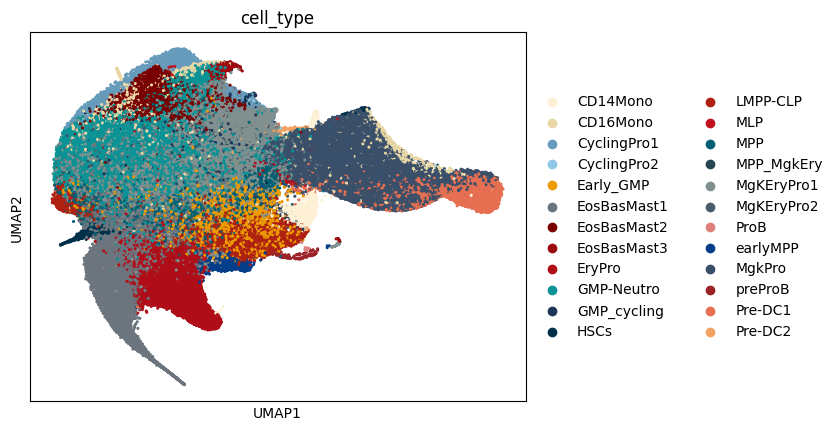

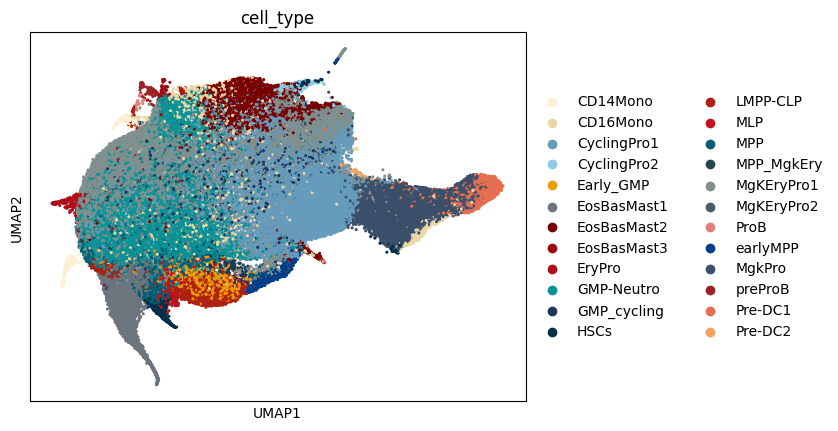

In [27]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

rename_map = {
    "late_MgkPro": "MgkPro",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
}

# Rename cell types
adata_loop2_plots.obs['cell_type'] = adata_loop2_plots.obs['cell_type'].replace(rename_map)
adata_loop2p5_plots.obs['cell_type'] = adata_loop2p5_plots.obs['cell_type'].replace(rename_map)

# Build ordered palette matching the cell types present in adata
cell_types = adata_loop2_plots.obs['cell_type'].cat.categories.tolist()
palette = [color_map.get(ct, '#cccccc') for ct in cell_types]

sc.pl.umap(adata_loop2_plots, color="cell_type", s=20, palette=palette)
sc.pl.umap(adata_loop2p5_plots, color="cell_type", s=20, palette=palette)

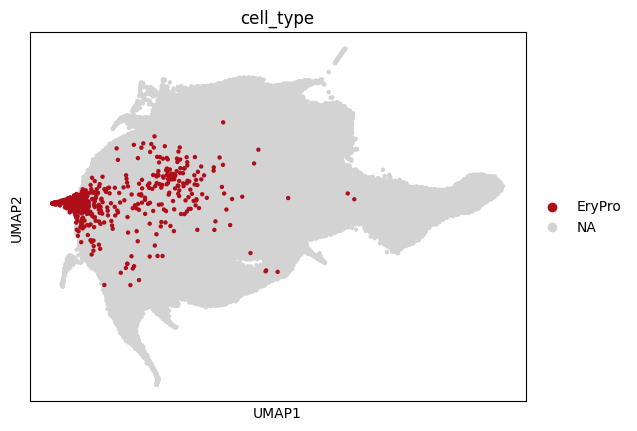

In [82]:
sc.pl.umap(adata_loop2p5_plots, color="cell_type", groups="EryPro", s=40)

## Check enrichments

In [43]:
adata_combined = sc.concat([adata_loop2_plots,adata_loop2p5_plots ])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [50]:
adata_combined.obs["cell_type"] = adata_combined.obs["cell_type"].astype("category")

In [51]:
protocols_loop2 = adata_combined.obs.loc[:, protocol_cols + ["experiment_number"]] 
protocols_loop2 = protocols_loop2.astype(float)

In [52]:
unique_protocols = pd.DataFrame(np.unique(protocols_loop2, axis=0))
unique_protocols.columns = protocols_loop2.columns

unique_protocols = unique_protocols.set_index("experiment_number")
unique_protocols["enriched_ct"] = None

In [54]:
unique_protocols.loc[239, "enriched_ct"] = "late_mgkPro_low_u"
unique_protocols.loc[240, "enriched_ct"] = "late_mgkPro_high_u0"
unique_protocols.loc[248, "enriched_ct"] = "late_mgkPro_high_u1"

unique_protocols.loc[241, "enriched_ct"] = "EryPro_low_u"
unique_protocols.loc[242, "enriched_ct"] = "EryPro_high_u0"
unique_protocols.loc[249, "enriched_ct"] = "EryPro_high_u1"

unique_protocols.loc[243, "enriched_ct"] = "HSC_low_u"
unique_protocols.loc[244, "enriched_ct"] = "HSC_high_u1"

unique_protocols.loc[245, "enriched_ct"] = "preProB_high_u0"
unique_protocols.loc[250, "enriched_ct"] = "preProB_low_u"
unique_protocols.loc[246, "enriched_ct"] = "preProB_low_u1"
unique_protocols.loc[251, "enriched_ct"] = "preProB_high_u2"

In [55]:
unique_protocols

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,enriched_ct
experiment_number,,,,,,,,,,,,,
239.0,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,20.0,14.0,late_mgkPro_low_u
240.0,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,10.0,14.0,late_mgkPro_high_u0
248.0,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,10.0,14.0,late_mgkPro_high_u1
243.0,7.10,3.40,579.20,1479.70,0.0,58.90,0.00,0.40,50.0,0.0,20.0,14.0,HSC_low_u
246.0,8.60,2.40,927.90,735.60,0.2,57.70,0.00,0.00,0.0,0.0,20.0,14.0,preProB_low_u1
250.0,8.70,2.50,754.30,1080.60,0.0,50.80,0.00,0.20,0.0,14.8,13.5,14.0,preProB_low_u
244.0,8.70,2.50,755.20,1064.10,0.0,51.00,0.00,0.30,0.0,14.2,13.5,14.0,HSC_high_u1
242.0,9.10,2.20,173.50,0.20,0.0,3.20,0.00,0.00,0.0,0.0,10.0,14.0,EryPro_high_u0
245.0,9.20,2.20,997.30,1120.20,0.0,57.20,0.00,0.00,0.1,0.6,20.0,14.0,preProB_high_u0


In [56]:
map_prot_to_ct = dict(zip(unique_protocols.index, unique_protocols.enriched_ct))

In [57]:
map_prot_to_ct

{239.0: 'late_mgkPro_low_u',
 240.0: 'late_mgkPro_high_u0',
 248.0: 'late_mgkPro_high_u1',
 243.0: 'HSC_low_u',
 246.0: 'preProB_low_u1',
 250.0: 'preProB_low_u',
 244.0: 'HSC_high_u1',
 242.0: 'EryPro_high_u0',
 245.0: 'preProB_high_u0',
 247.0: None,
 251.0: 'preProB_high_u2',
 249.0: 'EryPro_high_u1',
 241.0: 'EryPro_low_u'}

In [62]:
annot_combined = [map_prot_to_ct[float(exp_number)] for exp_number in  adata_combined.obs.experiment_number]

adata_combined.obs["Experiment_type"] = annot_combined

## Plot 

In [63]:
exp_number_ct_prop = {}

In [65]:
for exp_no in np.unique(adata_combined.obs.experiment_number):
    adata_exp = adata_combined[adata_combined.obs.experiment_number==exp_no]
    ct_prop = adata_exp.obs.cell_type.value_counts()
    for ct in classes:
        if ct not in ct_prop.index:
            ct_prop[ct] = 0
    exp_number_ct_prop[exp_no] = ct_prop

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


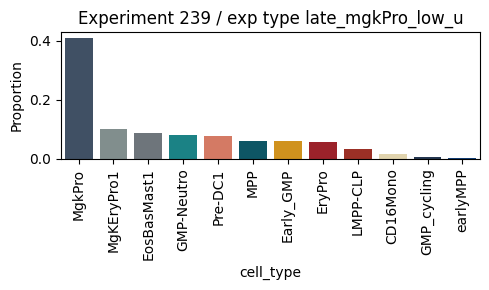

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


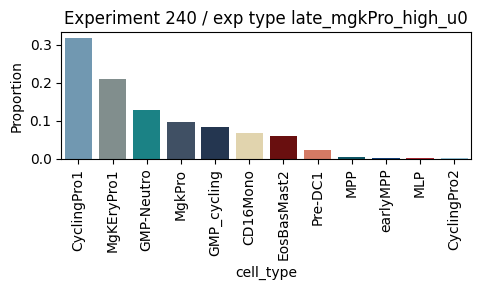

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


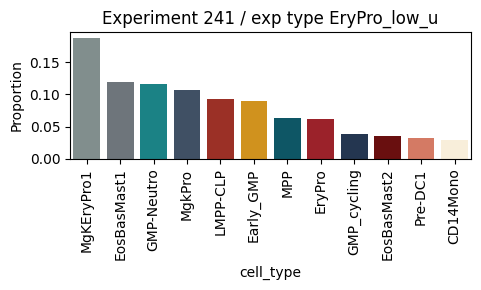

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


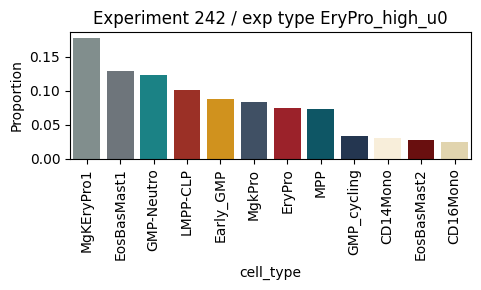

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


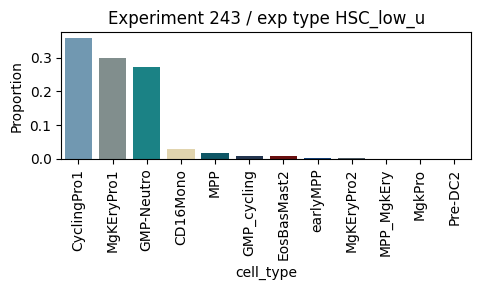

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


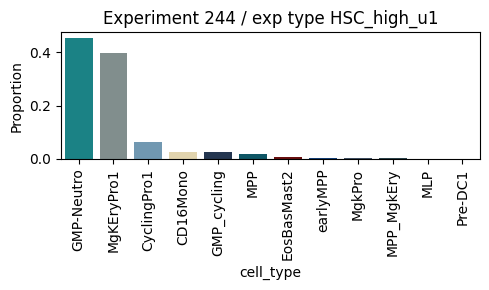

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


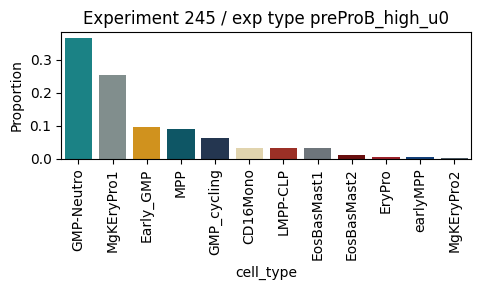

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


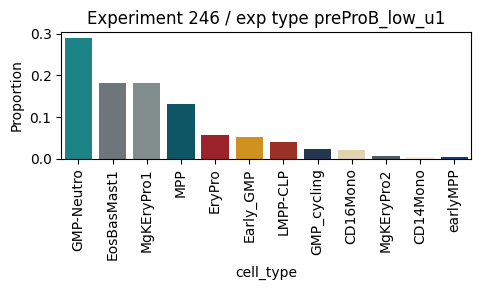

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


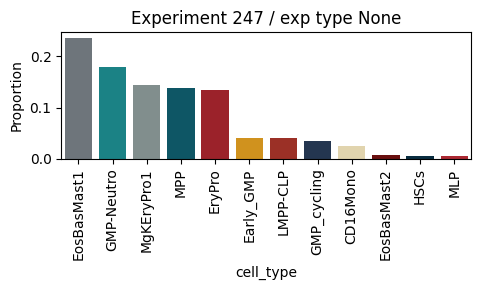

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


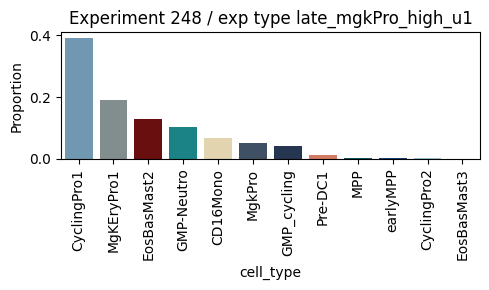

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


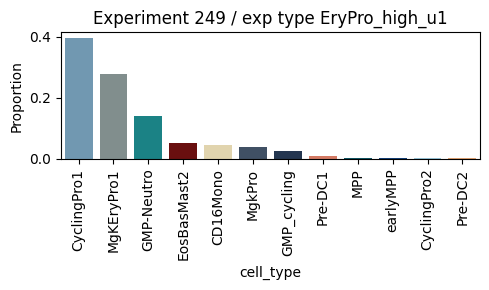

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


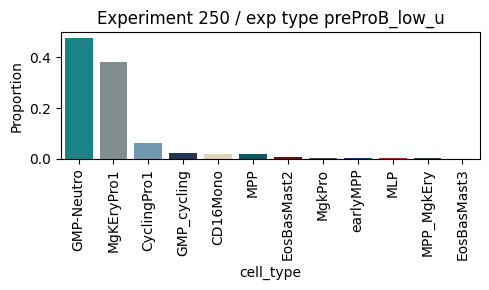

/tmp/ipykernel_624002/3581507380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
/tmp/ipykernel_624002/3581507380.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


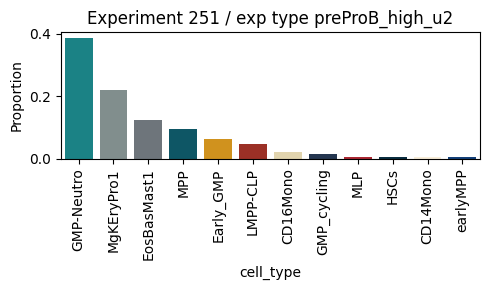

In [66]:
for exp_no in exp_number_ct_prop:
    
    data = exp_number_ct_prop[exp_no]
    # convert to proportions
    prop = data / data.sum()
    
    # Rename cell types
    prop.index = prop.index.map(lambda x: rename_map.get(x, x))
    
    # Keep only top 12 cell types by proportion
    prop = prop.nlargest(12)
    
    # Map colors to the cell types present in this experiment
    colors = [color_map.get(ct, '#cccccc') for ct in prop.index]
    
    fig, ax = plt.subplots(figsize=(5,3))
    sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")
    plt.tight_layout()
    
    # Save as SVG in .plots folder
    filename = f"experiment_{exp_no}_ct_proportions.svg"
    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Concatenate anndata

In [71]:
import anndata as ad

adata_combined = ad.concat(
    [adata_loop1, adata_combined])
adata_combined.obs["experiment_number"] = adata_combined.obs["experiment_number"].astype(str)
adata_combined.obs["count_beads"] = adata_combined.obs["count_beads"].astype(str)
adata_combined.obs["cell_counts"] = adata_combined.obs["count_beads"].astype(int)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


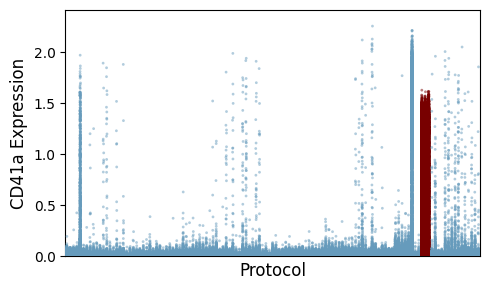

In [78]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD41a'] = adata_combined[:, 'CD41a'].X.toarray().flatten()

to_exclude = ["241", "242", "243", "244", "245", "246", "247", "249", "250", "251", "252"]
to_highlight = ["239", "240", "248"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)

# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)

fig, ax = plt.subplots(figsize=(5, 3))

sns.stripplot(
    data=plot_df,
    x="experiment_number",
    y="CD41a",
    hue="group",
    palette={
        "other": "#669bbc",
        "highlight": "#780000"
    },
    alpha=0.5,
    size=2,
    dodge=False,
    ax=ax
)

ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD41a Expression", fontsize=12)

# ax.tick_params(axis='x', rotation=90)
ax.set_xticks([])
ax.set_ylim(bottom=0)

# Optional: remove legend
ax.legend_.remove()

plt.tight_layout()

plt.show()
plt.close(fig)

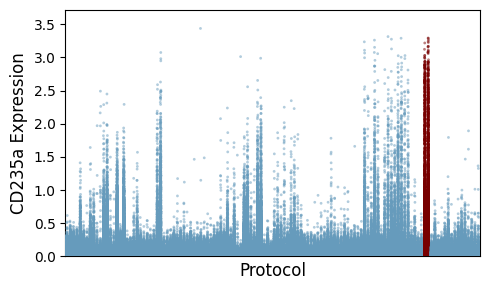

In [79]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD235a'] = adata_combined[:, 'CD235a'].X.toarray().flatten()

to_exclude = ["239", "240", "243", "244", "245", "246", "247", "248", "249", "250", "251"]
to_highlight = ["241", "242", "249"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)

# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)

fig, ax = plt.subplots(figsize=(5, 3))

sns.stripplot(
    data=plot_df,
    x="experiment_number",
    y="CD235a",
    hue="group",
    palette={
        "other": "#669bbc",
        "highlight": "#780000"
    },
    alpha=0.5,
    size=2,
    dodge=False,
    ax=ax
)

ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD235a Expression", fontsize=12)

# ax.tick_params(axis='x', rotation=90)
ax.set_xticks([])
ax.set_ylim(bottom=0)

# Optional: remove legend
ax.legend_.remove()

plt.tight_layout()

fig.savefig(
    "CD235a_216_217_218_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

In [83]:
# protocol_df = adata_loop2_copy.obs.loc[:, protocol_cols + ["experiment_number"]]
# protocol_df_old = adata_old_experiments.obs.loc[:, protocol_cols + ["experiment_number"]]

In [240]:
# mgk_pro_prot = protocol_df.loc[protocol_df.experiment_number.isin(["216", "217", "218"])].drop_duplicates()
# protocol_df_old_210 = protocol_df_old[protocol_df_old["experiment_number"]==210].drop_duplicates()
# protocol_df_old_210["experiment_number"] = protocol_df_old_210["experiment_number"].astype(str)
# protocol_df_old_210["experiment_number"] = "Best protocol befoere loop 2"
# joint_mgk = pd.concat([mgk_pro_prot, protocol_df_old_210])

In [84]:
# mgk_pro_prot = protocol_df.loc[
#     protocol_df.experiment_number.isin(["216", "217", "218"])
# ].drop_duplicates()

# protocol_df_old_210 = protocol_df_old[
#     protocol_df_old["experiment_number"] == 210
# ].drop_duplicates()

# protocol_df_old_210["experiment_number"] = "Best protocol before loop 2"

# # --- 2. Combine ---
# joint_mgk = pd.concat([mgk_pro_prot, protocol_df_old_210], axis=0)

# # --- 3. Order experiments ---
# exp_order = ["216", "217", "218", "Best protocol before loop 2"]

# joint_mgk["experiment_number"] = pd.Categorical(
#     joint_mgk["experiment_number"],
#     categories=exp_order,
#     ordered=True
# )

# # --- 4. Select protocol columns ---
# value_cols = [c for c in joint_mgk.columns if c != "experiment_number"]

# # --- 5. Melt to long format ---
# df_long = joint_mgk.melt(
#     id_vars="experiment_number",
#     value_vars=value_cols,
#     var_name="protocol",
#     value_name="value"
# )

# # --- 6. Clean data ---
# df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
# df_long = df_long.dropna(subset=["value"])
# df_long["protocol"] = df_long["protocol"].astype(str)

# # --- 7. Color palette (3 reds + old in blue-gray) ---
# palette = {
#     "216": "#4d0000",
#     "217": "#780000",
#     "218": "#b30000",
#     "Best protocol before loop 2": "#669bbc"
# }

# # --- 8. Plot ---
# plt.figure(figsize=(6, 3))

# sns.barplot(
#     data=df_long,
#     x="protocol",
#     y="value",
#     hue="experiment_number",
#     palette=palette
# )

# plt.xticks(rotation=90)
# plt.xlabel("Protocol")
# plt.ylabel("Value")

# plt.legend().remove()
# # plt.legend(
# #     frameon=False,
# #     loc="upper right",
# #     bbox_to_anchor=(1, 1)
# # )

# plt.tight_layout()

# plt.savefig(
#     "mgkpro_protocol_barplot.png",
#     dpi=500,
#     bbox_inches="tight"
# )
# plt.show()

EryPro

In [85]:
# import scanpy as sc
# protocol_adata = sc.read_h5ad("../protocol_adata.h5ad")

# protocol_adata.obs.EryPro.argmax()
# protocol_adata.obs.EryPro.argmax()

In [86]:
# ery_pro_prot = protocol_df.loc[protocol_df.experiment_number.isin(["219", "220", "221"])].drop_duplicates()
# protocol_df_old = pd.DataFrame((np.exp(protocol_adata.X[40])-1)[3:]).T
# protocol_df_old.columns = protocol_cols

In [87]:
# # --- 1. Build datasets ---
# ery_pro_prot = protocol_df.loc[
#     protocol_df.experiment_number.isin(["219", "220", "221"])
# ].drop_duplicates()

# protocol_df_old["experiment_number"] = "Best protocol before loop 2"

# # --- 2. Combine ---
# joint_ery = pd.concat([ery_pro_prot, protocol_df_old], axis=0)

# # --- 3. Order experiments ---
# exp_order = ["219", "220", "221", "Best protocol before loop 2"]

# joint_ery["experiment_number"] = pd.Categorical(
#     joint_ery["experiment_number"],
#     categories=exp_order,
#     ordered=True
# )

# # --- 4. Select protocol columns ---
# value_cols = [c for c in joint_ery.columns if c != "experiment_number"]

# # --- 5. Melt ---
# df_long = joint_ery.melt(
#     id_vars="experiment_number",
#     value_vars=value_cols,
#     var_name="protocol",
#     value_name="value"
# )

# # --- 6. Clean ---
# df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
# df_long = df_long.dropna(subset=["value"])
# df_long["protocol"] = df_long["protocol"].astype(str)

# # --- 7. Color palette (3 reds + old control) ---
# palette = {
#     "219": "#4d0000",
#     "220": "#780000",
#     "221": "#b30000",
#     "Best protocol before loop 2": "#669bbc"
# }

# # --- 8. Plot ---
# plt.figure(figsize=(6, 3))

# sns.barplot(
#     data=df_long,
#     x="protocol",
#     y="value",
#     hue="experiment_number",
#     palette=palette
# )

# plt.xticks(rotation=90)
# plt.xlabel("Protocol")
# plt.ylabel("Value")

# plt.legend(
#     frameon=False,
#     loc="upper right",
#     bbox_to_anchor=(1, 1)
# )
# # plt.legend().remove()

# plt.tight_layout()

# plt.savefig(
#     "erypro_protocol_barplot.png",
#     dpi=500,
#     bbox_inches="tight"
# )

# plt.show()